(text of intro)

In [1]:
import sys
import time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path[:0] = [str(ROOT), str(ROOT / "scripts")]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap

import alive_dead_features as adf
import metric_agreement as ma
import outline_variability as ov
from classes.analyzer import Analyzer
from classes.app_config import get_default_config
from classes import death_calibration
from classes.death_calibration import LabelledRun
from optuna_death_time import MAX_PAD

# The project's reporting module switches matplotlib to Agg (no figures) on import.
%matplotlib inline

# Chart style, as in death_time_calibration.ipynb: thin marks, recessive axes and grid, text in ink colours.
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8d8c85"
YELLOW, MAGENTA = "#eda100", "#e87ba4"
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3dc", "#fcfcfb"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.frameon": False, "legend.fontsize": 8.5, "lines.linewidth": 2,
})
# How much: one hue, light to dark. Which side: blue to red through grey.
AMOUNT = LinearSegmentedColormap.from_list("amount", [SURFACE, "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
SIDES = LinearSegmentedColormap.from_list("sides", ["#184f95", "#6da7ec", "#f0efec", "#ec8a89", "#a52a2a"])
pd.set_option("display.precision", 3)
pd.set_option("display.max_columns", 40)
np.seterr(invalid="ignore", divide="ignore")

run = adf.load_run()
seen = ov.measure(run)                    # the outline of every mite in every recording
profiles = seen["profiles"]               # (mites, recordings, directions): the variance on the outline, grey levels squared
table = ma.scores(run, legs=False)        # {metric: (mites, recordings)}, with config.yaml's parameters
n_mites, n_recordings = run.moving.shape
labelled, moving = run.labelled, run.moving
is_still = labelled & ~moving
truth = LabelledRun(np.zeros(moving.shape), moving, labelled)   # the labels, to count the deaths against
METRIC = ov.METRIC
WIDTH = ma.metric_params()[METRIC]["width"]   # how far the outline reaches on each side of the body's edge, pixels
N_FRAMES = int(np.load(run.path, mmap_mode="r").shape[2])
degrees = np.degrees(ov.ANGLE)

one_side = ov.one_sided(profiles)         # the vector sum around the mite: the one-sided part of the outline's variance. The score.
amount = ov.amount(profiles)              # how much the outline varies
share = ov.one_sidedness(profiles)        # how clustered: the one-sided part as a share of the amount. The score with relative 1.
RELATIVE = f"{METRIC}, relative 1"
assert np.allclose(one_side, table[METRIC], rtol=1e-4, atol=1e-5)  # the profiles give the score the app gives

def patch(mite, recording):
    """One mite's frames in one recording as the metric gets them: (frames, height, width, 3), its box and MAX_PAD pixels around it."""
    height, width = run.sizes[mite]
    return np.asarray(np.load(run.path, mmap_mode="r")[mite, recording, :, :height + 2 * MAX_PAD, :width + 2 * MAX_PAD])

def outline(mite, recording):
    """What the metric follows in one recording: the mite's centre (x, y) and how far the body's edge is from it in each direction, pixels."""
    _variance, edge, ray_step, centre = Analyzer._outline_rays(patch(mite, recording), MAX_PAD)
    return np.array(centre), edge * ray_step

def around(centre, radius):
    """The points `radius` (one per direction) from `centre`, as a closed line: (x, y)."""
    x, y = centre[0] + radius * np.cos(ov.ANGLE), centre[1] + radius * np.sin(ov.ANGLE)
    return np.append(x, x[0]), np.append(y, y[0])

def picture(ax, image, centre, reach=13, **shown):
    """An image of a mite's patch, cut to `reach` pixels around the mite, without axes."""
    drawn = ax.imshow(image, **shown)
    ax.set_xlim(centre[0] - reach, centre[0] + reach); ax.set_ylim(centre[1] + reach, centre[1] - reach)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for spine in ax.spines.values(): spine.set_visible(False)
    return drawn

def ring(ax, mite, recording, reach=13):
    """The mite with the variance of its outline drawn around it, one dot per direction, each ring on its own colour scale,
    and the vector sum as an arrow: it points to the side the variance lies on and is drawn as a share of the outline's
    variance, so that it reaches the dots when all of the variance is in one direction."""
    centre, edge = outline(mite, recording)
    profile = profiles[mite, recording]
    picture(ax, patch(mite, recording)[..., 0].mean(axis=0), centre, reach=reach, cmap="gray", vmin=15, vmax=125)
    x, y = around(centre, edge + 4)
    ax.scatter(x[:-1], y[:-1], c=profile, cmap=AMOUNT, vmin=0, vmax=profile.max(), s=17, linewidths=0, zorder=3)
    arrow = ov.pull(profile) / max(profile.mean(), 1e-12) * np.median(edge + 4)
    ax.annotate("", xy=(centre[0] + arrow.real, centre[1] + arrow.imag), xytext=tuple(centre),
                arrowprops=dict(arrowstyle="-|>", color=ORANGE, linewidth=1.6, shrinkA=0, shrinkB=0), zorder=4)

def rings(rows, title):
    """Rows of ring() pictures: {row name: [(mite, recording), ...]}, each with its score and the share on one side."""
    columns = max(len(cells) for cells in rows.values())
    fig, axes = plt.subplots(len(rows), columns, figsize=(1.63 * columns, 2.3 * len(rows)), squeeze=False)
    for row, (name, cells) in enumerate(rows.items()):
        for ax, (mite, recording) in zip(axes[row], cells):
            ring(ax, mite, recording)
            ax.set_title(f"mite {run.mites[mite]}, rec. {recording}\nscore {one_side[mite, recording]:.2f}\n{share[mite, recording]:.0%} on one side", fontsize=7.5)
        for ax in axes[row, len(cells):]:
            ax.axis("off")
        axes[row, 0].set_ylabel(name, fontsize=8.5)
    fig.suptitle(title, fontsize=11, fontweight="bold", color=INK, x=0.01, ha="left")
    plt.tight_layout(w_pad=0.4, h_pad=0.9)
    plt.show()

def shown(frame, formats):
    """Shows a table with the numbers of some columns written out: {column: format}."""
    out = frame.copy()
    for column, form in formats.items():
        out[column] = out[column].map(form.format)
    display(out)

def at_quantiles(values, where, quantiles):
    """The (mite, recording)s of `where` whose values are at those quantiles of them."""
    cells = np.argwhere(where)
    order = np.argsort(values[where], kind="stable")
    return [tuple(cells[order[int(round(quantile * (len(cells) - 1)))]]) for quantile in quantiles]

print(f"{run.name}: {n_mites} mites, {n_recordings} recordings of {N_FRAMES} frames, {np.median(np.diff(run.times)):g} minutes apart")
print(f"labelled by eye: {labelled.sum()} mite-recordings, {moving.sum()} of them moving ({moving.sum() / labelled.sum():.1%}), {is_still.sum()} still")
print(f"{METRIC}: {Analyzer.metric_description(METRIC)}")
print(f"  parameters: {ma.metric_params()[METRIC]}")

  test_run_2026-09-08_Mathis_last_dsRNA: 59 mites, 295 recordings
test_run_2026-09-08_Mathis_last_dsRNA: 59 mites, 295 recordings of 10 frames, 10 minutes apart
labelled by eye: 17318 mite-recordings, 651 of them moving (3.8%), 16667 still
outline_variability: Vector sum around the mite of the variance of the pixels on its outline: how much of that variance lies on one side.
  parameters: {'relative': 0.0, 'width': 1.5, 'pad': 16}


(text of where)

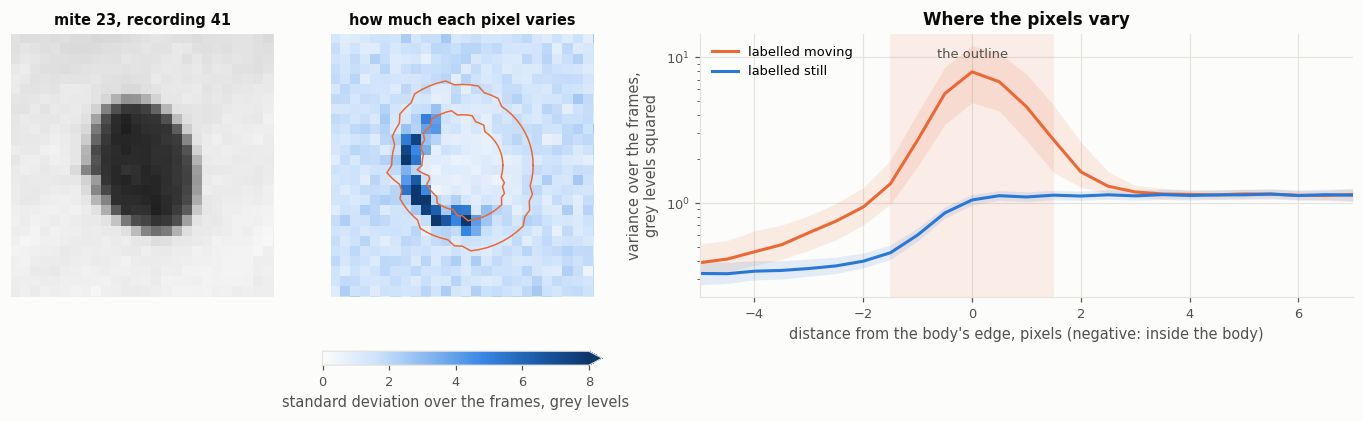

of the variance a mite labelled moving has more than one labelled still, 89% is within 1.5 px of the body's edge, 5% further out and 6% further in
at the edge, the variance is 7.9 in the middle of the recordings labelled moving and 1.0 of those labelled still
a still mite: 0.34 on the body (4 px inside the edge), 1.13 on the bare plate (5 px outside): the camera's noise, larger where it is brighter
this mite's box, which variability takes the mean over, holds 169 pixels; its outline, between the two orange lines, about 116, 87 of them in the box


In [2]:
EXAMPLE = at_quantiles(one_side, moving, [0.75])[0]        # a recording labelled moving with a clear movement
frames = patch(*EXAMPLE)[..., 0]
centre, edge = outline(*EXAMPLE)
by_distance = seen["by_distance"]                           # (mites, recordings, distances from the body's edge)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.7), gridspec_kw={"width_ratios": [1, 1, 2.1]}, constrained_layout=True)
picture(axes[0], frames.mean(axis=0), centre, cmap="gray", vmin=15, vmax=125)
axes[0].set_title(f"mite {run.mites[EXAMPLE[0]]}, recording {EXAMPLE[1]}", fontsize=9.5)
drawn = picture(axes[1], frames.std(axis=0), centre, cmap=AMOUNT, vmin=0, vmax=8)
for radius in (edge - WIDTH, edge + WIDTH):
    axes[1].plot(*around(centre, radius), color=ORANGE, linewidth=1)
axes[1].set_title("how much each pixel varies", fontsize=9.5)
fig.colorbar(drawn, ax=axes[1], location="bottom", shrink=0.9, pad=0.03, extend="max", label="standard deviation over the frames, grey levels")

ax = axes[2]
ax.axvspan(-WIDTH, WIDTH, color=ORANGE, alpha=0.10, linewidth=0)
for where, color, name in ((moving, ORANGE, "labelled moving"), (is_still, BLUE, "labelled still")):
    low, middle, high = np.nanpercentile(by_distance[where], [25, 50, 75], axis=0)
    ax.fill_between(ov.OFFSETS, low, high, color=color, alpha=0.12, linewidth=0)
    ax.plot(ov.OFFSETS, middle, color=color, label=name)
ax.set_yscale("log")
ax.set_xlim(ov.OFFSETS[0], ov.OFFSETS[-1])
ax.set(xlabel="distance from the body's edge, pixels (negative: inside the body)", ylabel="variance over the frames,\ngrey levels squared",
       title="Where the pixels vary")
ax.text(0, ax.get_ylim()[1] * 0.8, "the outline", ha="center", va="top", fontsize=8.5, color=MUTED)
ax.legend(loc="upper left")
plt.show()

more = np.nanmean(by_distance[moving], axis=0) - np.nanmean(by_distance[is_still], axis=0)    # what a moving mite has more than a still one
on_outline = np.abs(ov.OFFSETS) <= WIDTH
print(f"of the variance a mite labelled moving has more than one labelled still, {more[on_outline].sum() / more.sum():.0%} is within {WIDTH:g} px "
      f"of the body's edge, {more[ov.OFFSETS > WIDTH].sum() / more.sum():.0%} further out and {more[ov.OFFSETS < -WIDTH].sum() / more.sum():.0%} further in")
middle = lambda where, at: np.nanmedian(by_distance[where][:, np.isclose(ov.OFFSETS, at)])
print(f"at the edge, the variance is {middle(moving, 0):.1f} in the middle of the recordings labelled moving and {middle(is_still, 0):.1f} of those labelled still")
print(f"a still mite: {middle(is_still, -4):.2f} on the body (4 px inside the edge), {middle(is_still, 5):.2f} on the bare plate (5 px outside): the camera's noise, larger where it is brighter")
height, width = run.sizes[EXAMPLE[0]]
box = np.zeros(frames.shape[1:], dtype=bool)
box[MAX_PAD:MAX_PAD + height, MAX_PAD:MAX_PAD + width] = True
yy, xx = np.mgrid[:frames.shape[1], :frames.shape[2]]
angle_at = np.round(np.degrees(np.arctan2(yy - centre[1], xx - centre[0])) % 360 / (360 / ov.ANGLES)).astype(int) % ov.ANGLES
band = np.abs(np.hypot(yy - centre[1], xx - centre[0]) - edge[angle_at]) <= WIDTH
print(f"this mite's box, which variability takes the mean over, holds {box.sum()} pixels; its outline, between the two orange lines, about {band.sum()}, "
      f"{(band & box).sum()} of them in the box")

(text of unrolled)

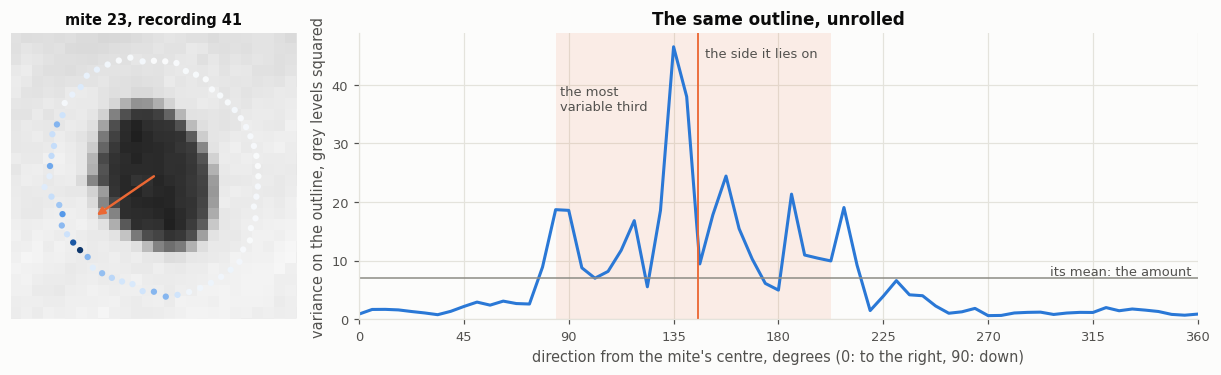

amount 6.99; vector sum 4.40, toward 146 degrees: the score; that is 63% of the amount on one side; 74% of the variance is in the most variable third of the outline (shaded)


In [3]:
profile = profiles[EXAMPLE]
third = ov.ANGLES // 3
start = int(sum(np.roll(profile, -shift) for shift in range(third)).argmax())            # where the most variable third starts

fig, axes = plt.subplots(1, 2, figsize=(11, 3.3), gridspec_kw={"width_ratios": [1, 2.9]}, constrained_layout=True)
ring(axes[0], *EXAMPLE)
axes[0].set_title(f"mite {run.mites[EXAMPLE[0]]}, recording {EXAMPLE[1]}", fontsize=9.5)
ax = axes[1]
for first, end in ((start, min(start + third, ov.ANGLES)), (0, start + third - ov.ANGLES)):
    if end > first:
        ax.axvspan(degrees[first], degrees[first] + (end - first) * 360 / ov.ANGLES, color=ORANGE, alpha=0.10, linewidth=0)
ax.plot(np.append(degrees, 360), np.append(profile, profile[0]), color=BLUE)
ax.axhline(profile.mean(), color=GREY, linewidth=1)
ax.text(359, profile.mean(), "its mean: the amount ", ha="right", va="bottom", fontsize=8.5, color=MUTED)
ax.axvline(ov.direction(profile), color=ORANGE, linewidth=1.2)
ax.text(ov.direction(profile) + 3, profile.max(), "the side it lies on", ha="left", va="top", fontsize=8.5, color=MUTED)
ax.text(degrees[start] + 2, profile.max() * 0.86, "the most\nvariable third", ha="left", va="top", fontsize=8.5, color=MUTED)
ax.set_xlim(0, 360); ax.set_xticks(range(0, 361, 45)); ax.set_ylim(0, None)
ax.set(xlabel="direction from the mite's centre, degrees (0: to the right, 90: down)", ylabel="variance on the outline, grey levels squared",
       title="The same outline, unrolled")
plt.show()
print(f"amount {ov.amount(profile):.2f}; vector sum {ov.one_sided(profile):.2f}, toward {ov.direction(profile):.0f} degrees: the score; "
      f"that is {ov.one_sidedness(profile):.0%} of the amount on one side; {ov.share(profile):.0%} of the variance is in the most variable third of the outline (shaded)")

(text of gallery)

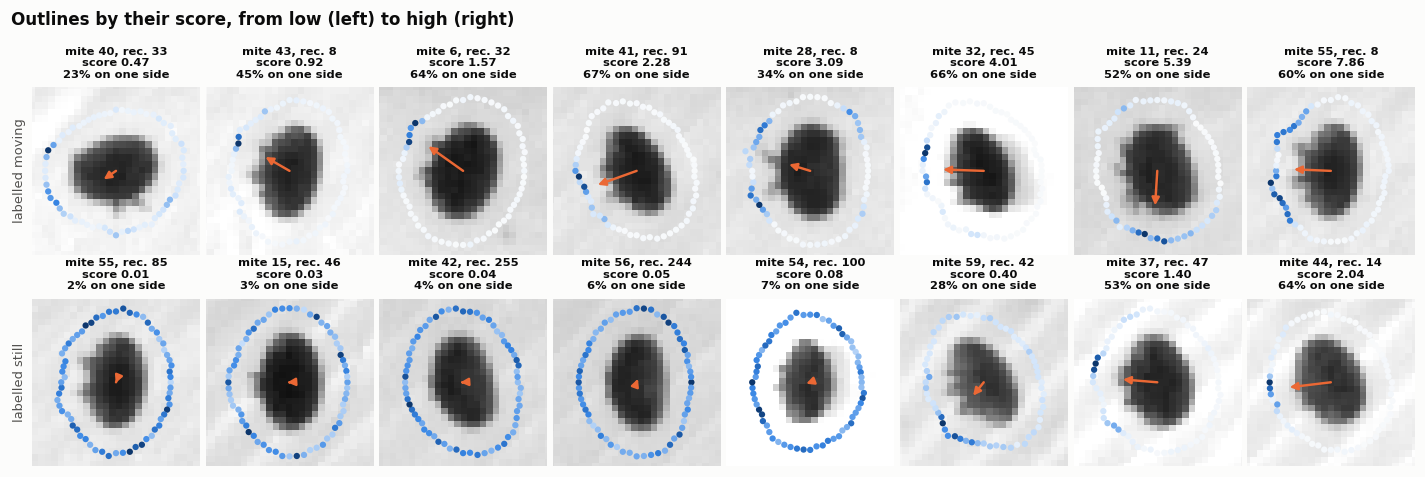

In [4]:
rings({"labelled moving": at_quantiles(one_side, moving, (0.03, 0.1, 0.25, 0.4, 0.55, 0.7, 0.85, 0.97)),
       "labelled still": at_quantiles(one_side, is_still, (0.1, 0.3, 0.5, 0.7, 0.9, 0.99, 0.999, 1.0))},
      "Outlines by their score, from low (left) to high (right)")

(text of clustered)

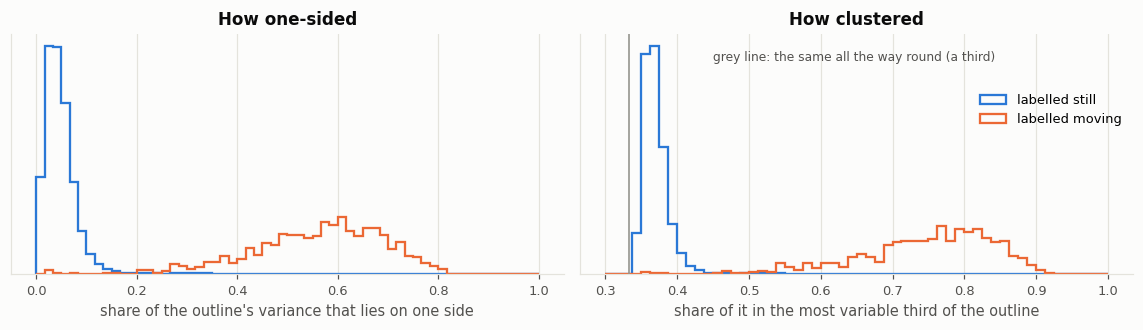

,recordings,on one side: median,from,to,in the most variable third: median,within 60 degrees of the mite's own side
labelled moving,651,0.578,0.482,0.658,0.764,0.990
labelled still,16667,0.043,0.027,0.062,0.367,0.481


the mite's own side: the side its variance is on in its other recordings labelled moving, for the 46 mites with 4 or more of them. By chance a third of the recordings would be within 60 degrees of it.

recordings with at least that share on one side:


,0.1,0.2,0.3,0.4,0.5,0.6
"labelled still, of 16667",977,247,147,74,30,8
"labelled moving, of 651",646,644,622,574,458,277


In [5]:
in_third = ov.share(profiles)
toward = ov.toward_own_side(run, profiles)          # the cosine between a recording's side and the side of the mite's other moving recordings

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.1))
for ax, values, bins, xlabel in ((axes[0], share, np.linspace(0, 1, 61), "share of the outline's variance that lies on one side"),
                                 (axes[1], in_third, np.linspace(0.3, 1, 57), "share of it in the most variable third of the outline")):
    ax.hist(values[is_still], bins=bins, density=True, histtype="step", linewidth=1.5, color=BLUE, label="labelled still")
    ax.hist(values[moving], bins=bins, density=True, histtype="step", linewidth=1.5, color=ORANGE, label="labelled moving")
    ax.set_yticks([]); ax.set_xlabel(xlabel); ax.grid(axis="y", visible=False)
axes[0].set_title("How one-sided")
axes[1].set_title("How clustered")
axes[1].axvline(1 / 3, color=GREY, linewidth=1)
axes[1].text(0.45, axes[1].get_ylim()[1] * 0.93, "grey line: the same all the way round (a third)", fontsize=8, color=MUTED, va="top")
axes[1].legend(loc="upper right", bbox_to_anchor=(1, 0.8))
plt.tight_layout()
plt.show()

rows = {}
for name, where in (("labelled moving", moving), ("labelled still", is_still)):
    known = where & np.isfinite(toward)
    rows[name] = {"recordings": int(where.sum()),
                  "on one side: median": np.median(share[where]), "from": np.percentile(share[where], 25), "to": np.percentile(share[where], 75),
                  "in the most variable third: median": np.median(in_third[where]),
                  "within 60 degrees of the mite's own side": (toward[known] > 0.5).mean()}
display(pd.DataFrame(rows).T.astype({"recordings": int}))
print(f"the mite's own side: the side its variance is on in its other recordings labelled moving, for the {int(np.isfinite(toward).any(axis=1).sum())} mites "
      f"with 4 or more of them. By chance a third of the recordings would be within 60 degrees of it.")

# the same in counts: the two histograms above have the same area, and there are 26 still recordings for every moving one
levels = (0.1, 0.2, 0.3, 0.4, 0.5, 0.6)
print("\nrecordings with at least that share on one side:")
display(pd.DataFrame({f"{level:g}": {f"labelled still, of {is_still.sum()}": int((share[is_still] >= level).sum()),
                                     f"labelled moving, of {moving.sum()}": int((share[moving] >= level).sum())} for level in levels}))

(text of score)

In [6]:
SCORES = {"variability": table["variability"], "vector_variance": table["vector_variance"], "outline_movement": table["outline_movement"],
          METRIC: one_side, RELATIVE: share, "the outline's whole variance": amount}
judged = {name: ov.judged(values, run) for name, values in SCORES.items()}
CALLS = {name: values >= judged[name]["threshold"] for name, values in SCORES.items()}      # each at its best threshold for the deaths

rows = {}
for name, result in judged.items():
    floors = np.array([np.median(SCORES[name][mite][is_still[mite]]) for mite in range(n_mites)])        # each mite's own floor
    rows[name] = {"AUC": result["auc"], "moving found, 1 still in 1000 called": result["found"], "kappa with the labels": result["kappa"],
                  "death error, recordings": result["death_error"], "at the threshold": result["threshold"],
                  "mites dying later": result["later"], "earlier": result["earlier"],
                  "called moving there": int((CALLS[name] & labelled).sum()), "of them still": int((CALLS[name] & is_still).sum()),
                  "moving missed": int((~CALLS[name] & moving).sum()),
                  "threshold over the still median": result["threshold"] / np.median(SCORES[name][is_still]),
                  "mites' own floors, share of the threshold": f"{floors.min() / result['threshold']:.0%} to {floors.max() / result['threshold']:.0%}"}
whole = ["mites dying later", "earlier", "called moving there", "of them still", "moving missed"]
shown(pd.DataFrame(rows).T.astype({column: int for column in whole}),
      {"AUC": "{:.4f}", "moving found, 1 still in 1000 called": "{:.1%}", "kappa with the labels": "{:.3f}",
       "death error, recordings": "{:.2f}", "at the threshold": "{:.4g}", "threshold over the still median": "{:.1f}"})

in_use = get_default_config().mite.metric
if ("variability", in_use) in ma.same(table):
    print(f"the score in use, {in_use} with config.yaml's parameters, is the same numbers as variability here")
print("how much of a difference is the luck of which mites were on the plate (the mites drawn again 500 times, the middle 95 in 100 of the draws):")
pairs = [(METRIC, one_side, "variability", SCORES["variability"]),
         (METRIC, one_side, "outline_movement", SCORES["outline_movement"]),
         ("the outline's whole variance", amount, METRIC, one_side),
         (RELATIVE, share, METRIC, one_side),
         ("the share in the most variable third", in_third, RELATIVE, share),
         ("the share in the most variable half", ov.share(profiles, ov.ANGLES // 2), RELATIVE, share)]
for first, values, second, others in pairs:
    again = ov.drawn_again(values, others, run)
    auc, error = (np.percentile(again[key], [2.5, 50, 97.5]) for key in ("auc", "death_error"))
    print(f"  {first} minus {second}: AUC {auc[1]:+.4f} ({auc[0]:+.4f} to {auc[2]:+.4f}), higher in {np.mean(again['auc'] > 0):.0%} of the draws; "
          f"death error {error[1]:+.2f} ({error[0]:+.2f} to {error[2]:+.2f}) recordings")

,AUC,"moving found, 1 still in 1000 called",kappa with the labels,"death error, recordings",at the threshold,mites dying later,earlier,called moving there,of them still,moving missed,threshold over the still median,"mites' own floors, share of the threshold"
variability,0.9974,82.8%,0.912,3.49,4.175,0,15,511,2,142,2.7,30% to 50%
vector_variance,0.9923,77.4%,0.898,3.64,375.3,1,14,490,8,169,10.9,4% to 17%
outline_movement,0.9967,78.5%,0.911,4.22,0.2665,3,16,542,20,129,2.7,32% to 47%
outline_variability,0.9965,79.6%,0.904,3.44,1.638,0,15,477,5,179,42.8,2% to 5%
"outline_variability, relative 1",0.9941,55.8%,0.879,5.90,0.4603,9,9,562,44,133,10.8,8% to 15%
the outline's whole variance,0.9983,84.0%,0.911,3.42,3.015,0,15,513,2,140,3.4,27% to 37%


the score in use, topN_variability with config.yaml's parameters, is the same numbers as variability here
how much of a difference is the luck of which mites were on the plate (the mites drawn again 500 times, the middle 95 in 100 of the draws):


  outline_variability minus variability: AUC -0.0008 (-0.0030 to +0.0007), higher in 19% of the draws; death error -0.05 (-0.24 to +0.10) recordings


  outline_variability minus outline_movement: AUC -0.0001 (-0.0025 to +0.0016), higher in 46% of the draws; death error -0.76 (-1.60 to -0.17) recordings


  the outline's whole variance minus outline_variability: AUC +0.0017 (+0.0002 to +0.0039), higher in 99% of the draws; death error +0.00 (-0.14 to +0.07) recordings


  outline_variability, relative 1 minus outline_variability: AUC -0.0022 (-0.0047 to -0.0009), higher in 0% of the draws; death error +2.41 (+0.17 to +5.33) recordings


  the share in the most variable third minus outline_variability, relative 1: AUC +0.0008 (-0.0009 to +0.0033), higher in 76% of the draws; death error +0.02 (-0.83 to +1.02) recordings


  the share in the most variable half minus outline_variability, relative 1: AUC +0.0015 (-0.0000 to +0.0041), higher in 97% of the draws; death error -0.62 (-1.96 to +0.18) recordings


(text of differs)

outline_variability at 1.64 calls 477 recordings moving: 472 of the 651 labelled moving, and 5 labelled still
  the 5 labelled still: 5 are before the mite's last labelled movement, 0 within 6 recordings (an hour) after it, 0 from 7 to 30 recordings after it and 0 later
    their variance is within 60 degrees of the mite's own side in 3 of the 3 whose mite has one (by chance a third); their outline varies by 2.9 in the middle (a still recording's by 0.9, a moving one's by 4.7)
  the 179 labelled moving it misses: their outline varies by 2.5 in the middle, 43% of it on one side; the ones it finds by 5.8, 61% on one side
  46 of the missed variability finds at its threshold, and 9 that variability misses the score finds


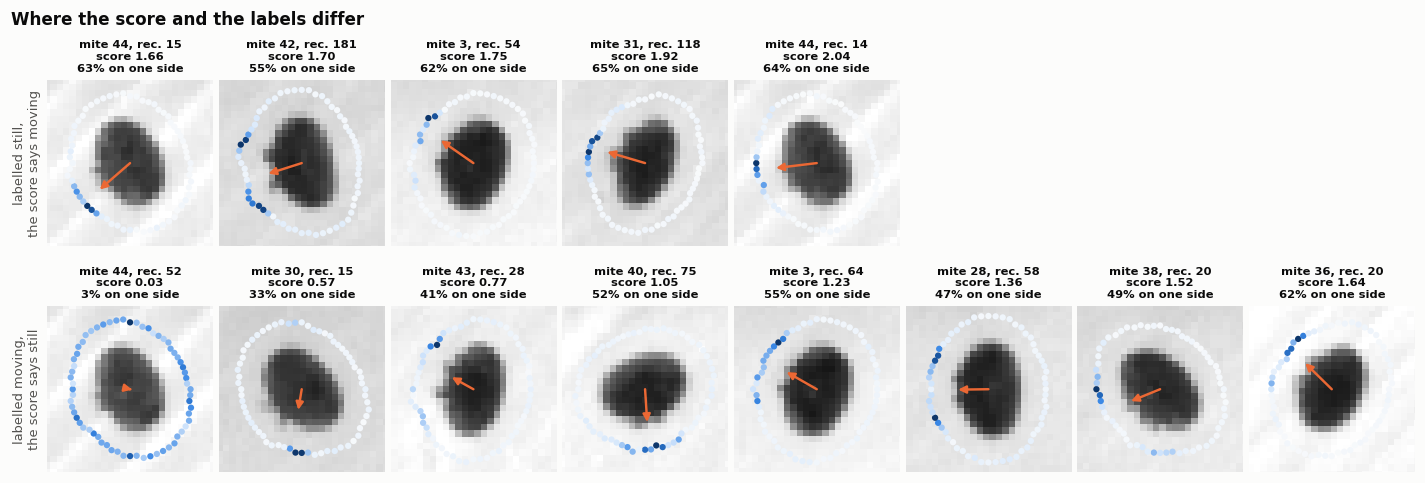

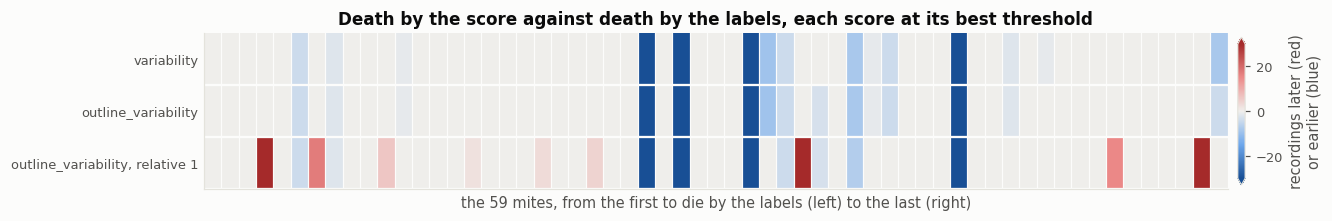

,same recording,within 3 recordings,more than 3 later,more than 3 earlier,latest,earliest,mean distance
variability,44,49,0,10,0,-44,3.492
outline_variability,44,49,0,10,0,-44,3.441
"outline_variability, relative 1",41,45,7,7,66,-44,5.898


In [7]:
called = CALLS[METRIC]
threshold = judged[METRIC]["threshold"]
recording = np.arange(n_recordings)[None]
last = run.last[:, None]                                  # each mite's last labelled movement

def against_labels(name, values, called):
    # where the calls of one score and the labels differ: the recordings (extra, missed)
    extra, missed = called & is_still, ~called & moving
    after = extra & (recording > last)
    print(f"{name} at {judged[name]['threshold']:.3g} calls {(called & labelled).sum()} recordings moving: {(called & moving).sum()} of the {moving.sum()} labelled moving, "
          f"and {extra.sum()} labelled still")
    print(f"  the {extra.sum()} labelled still: {(extra & (recording < last)).sum()} are before the mite's last labelled movement, "
          f"{(after & (recording <= last + 6)).sum()} within 6 recordings (an hour) after it, "
          f"{(after & (recording > last + 6) & (recording <= last + 30)).sum()} from 7 to 30 recordings after it and {(after & (recording > last + 30)).sum()} later")
    if after.any():
        print(f"    the {after.sum()} after it, as mite/recording (recordings after the last labelled movement): "
              + ", ".join(f"{run.mites[mite]}/{at} (+{at - run.last[mite]})" for mite, at in np.argwhere(after)))
    known = extra & np.isfinite(toward)
    print(f"    their variance is within 60 degrees of the mite's own side in {(toward[known] > 0.5).sum()} of the {known.sum()} whose mite has one (by chance a third); "
          f"their outline varies by {np.median(amount[extra]):.1f} in the middle (a still recording's by {np.median(amount[is_still]):.1f}, a moving one's by {np.median(amount[moving]):.1f})")
    print(f"  the {missed.sum()} labelled moving it misses: their outline varies by {np.median(amount[missed]):.1f} in the middle, {np.median(share[missed]):.0%} of it on one side; "
          f"the ones it finds by {np.median(amount[called & moving]):.1f}, {np.median(share[called & moving]):.0%} on one side")
    return extra, missed

extra, missed = against_labels(METRIC, one_side, called)
print(f"  {(missed & CALLS['variability']).sum()} of the missed variability finds at its threshold, and {(~CALLS['variability'] & moving & called).sum()} that variability misses the score finds")
rings({"labelled still,\nthe score says moving": at_quantiles(one_side, extra, np.linspace(0, 1, min(8, int(extra.sum())))),
       "labelled moving,\nthe score says still": at_quantiles(one_side, missed, np.linspace(0, 1, 8))},
      "Where the score and the labels differ")

# what it does to the deaths, mite by mite
NAMES = ["variability", METRIC, RELATIVE]
errors = np.array([truth.death_errors(CALLS[name]) for name in NAMES])
by_death = np.argsort(np.where(run.moved, run.last, -1), kind="stable")
fig, ax = plt.subplots(figsize=(12, 1.9), constrained_layout=True)
drawn = ax.imshow(errors[:, by_death], aspect="auto", cmap=SIDES, vmin=-30, vmax=30, interpolation="nearest")
ax.set_yticks(range(len(NAMES)), NAMES)
ax.set_xticks([]); ax.grid(False); ax.tick_params(length=0)
ax.set_xlabel(f"the {n_mites} mites, from the first to die by the labels (left) to the last (right)")
for line in np.arange(0.5, len(NAMES)):
    ax.axhline(line, color=SURFACE, linewidth=1.5)
for line in np.arange(0.5, n_mites):
    ax.axvline(line, color=SURFACE, linewidth=0.8)
ax.set_title("Death by the score against death by the labels, each score at its best threshold")
fig.colorbar(drawn, ax=ax, shrink=0.95, pad=0.01, extend="both", label="recordings later (red)\nor earlier (blue)")
plt.show()
display(pd.DataFrame({name: {"same recording": int((error == 0).sum()), "within 3 recordings": int((np.abs(error) <= 3).sum()),
                             "more than 3 later": int((error > 3).sum()), "more than 3 earlier": int((error < -3).sum()),
                             "latest": int(error.max()), "earliest": int(error.min()), "mean distance": float(np.abs(error).mean())}
                      for name, error in zip(NAMES, errors)}).T
        .astype({column: int for column in ("same recording", "within 3 recordings", "more than 3 later", "more than 3 earlier", "latest", "earliest")}))

(text of relative)

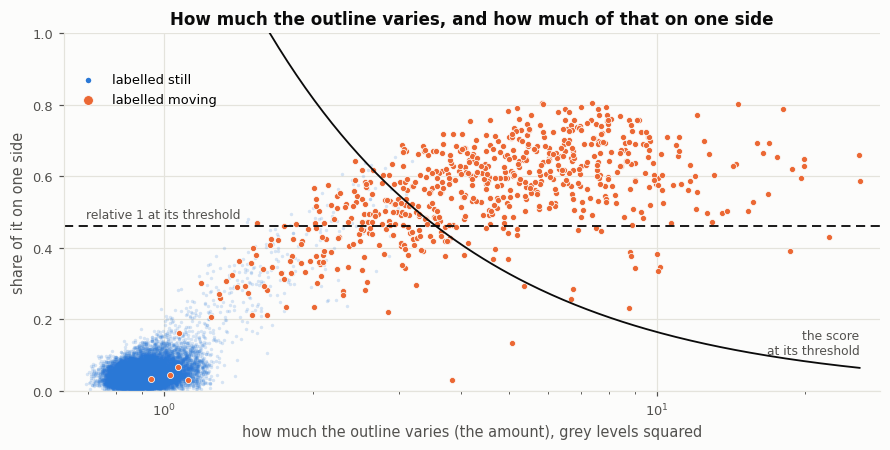

,AUC,"moving found, 1 still in 1000 called",kappa with the labels,"death error, recordings",at the threshold,mites dying later,earlier
relative 0,0.9965,79.6%,0.904,3.44,1.638,0,15
relative 0.25,0.9962,77.7%,0.903,3.92,1.295,0,17
relative 0.5,0.9957,74.8%,0.903,4.29,1.021,0,19
relative 0.75,0.9951,68.5%,0.895,5.68,0.8166,0,24
relative 1,0.9941,55.8%,0.879,5.90,0.4603,9,9


labelled moving (651): called moving by both 447, by the score alone 25, with relative 1 alone 71, by neither 108
labelled still (16667): called moving by both 5, by the score alone 0, with relative 1 alone 39, by neither 16623

outline_variability, relative 1 at 0.46 calls 562 recordings moving: 518 of the 651 labelled moving, and 44 labelled still
  the 44 labelled still: 32 are before the mite's last labelled movement, 5 within 6 recordings (an hour) after it, 4 from 7 to 30 recordings after it and 3 later
    the 12 after it, as mite/recording (recordings after the last labelled movement): 0/139 (+15), 4/32 (+3), 19/38 (+4), 20/86 (+30), 21/23 (+17), 22/24 (+4), 22/26 (+6), 30/237 (+52), 30/251 (+66), 36/25 (+2), 54/19 (+20), 54/30 (+31)
    their variance is within 60 degrees of the mite's own side in 36 of the 36 whose mite has one (by chance a third); their outline varies by 2.4 in the middle (a still recording's by 0.9, a moving one's by 4.7)
  the 133 labelled moving it misses

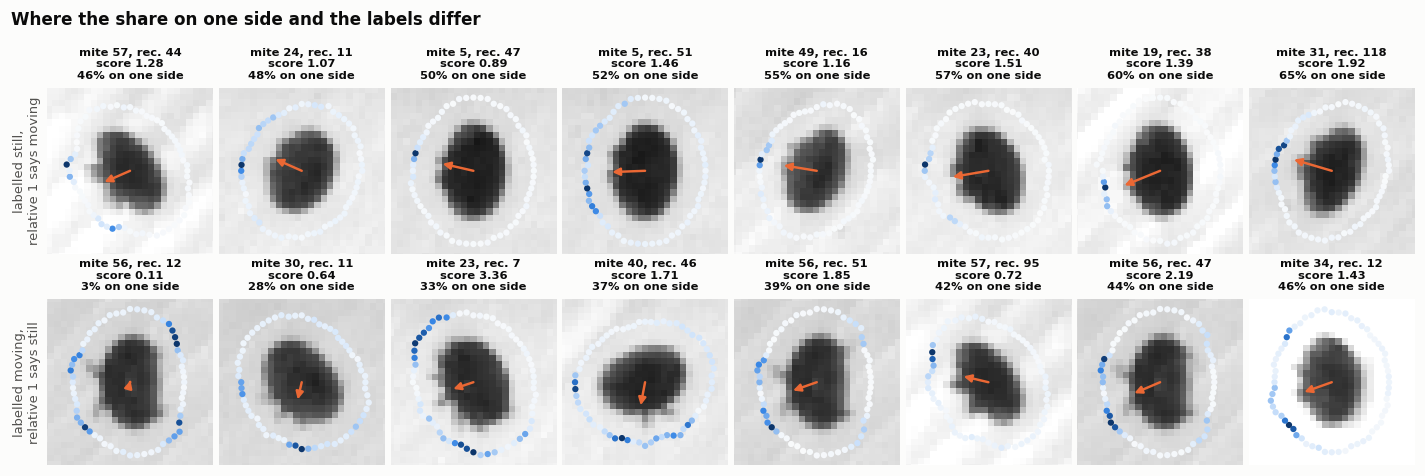

In [8]:
best_share = judged[RELATIVE]["threshold"]
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.scatter(amount[is_still], share[is_still], s=5, color=BLUE, alpha=0.18, linewidths=0, rasterized=True, label="labelled still")
ax.scatter(amount[moving], share[moving], s=16, color=ORANGE, edgecolors=SURFACE, linewidths=0.5, label="labelled moving")
across = np.geomspace(threshold, amount[labelled].max(), 200)
ax.plot(across, threshold / across, color=INK, linewidth=1.2)
ax.axhline(best_share, color=INK, linewidth=1.2, linestyle=(0, (5, 3)))
ax.text(across[-1], threshold / across[-1] + 0.03, "the score\nat its threshold", ha="right", va="bottom", fontsize=8, color=MUTED)
ax.text(amount[labelled].min(), best_share + 0.015, "relative 1 at its threshold", ha="left", va="bottom", fontsize=8, color=MUTED)
ax.set_xscale("log"); ax.set_ylim(0, 1); ax.set_xlim(amount[labelled].min() * 0.9, amount[labelled].max() * 1.1)
ax.set(xlabel="how much the outline varies (the amount), grey levels squared", ylabel="share of it on one side",
       title="How much the outline varies, and how much of that on one side")
legend = ax.legend(loc="upper left", bbox_to_anchor=(0, 0.92), markerscale=1.6)
for handle in legend.legend_handles: handle.set_alpha(1)
plt.tight_layout()
plt.show()

dial = {relative: ov.judged(ov.score(profiles, relative), run) for relative in (0, 0.25, 0.5, 0.75, 1)}
shown(pd.DataFrame({f"relative {relative:g}": {"AUC": result["auc"], "moving found, 1 still in 1000 called": result["found"], "kappa with the labels": result["kappa"],
                                               "death error, recordings": result["death_error"], "at the threshold": result["threshold"],
                                               "mites dying later": result["later"], "earlier": result["earlier"]}
                    for relative, result in dial.items()}).T.astype({"mites dying later": int, "earlier": int}),
      {"AUC": "{:.4f}", "moving found, 1 still in 1000 called": "{:.1%}", "kappa with the labels": "{:.3f}",
       "death error, recordings": "{:.2f}", "at the threshold": "{:.4g}"})

by_share = CALLS[RELATIVE]
for name, where in (("labelled moving", moving), ("labelled still", is_still)):
    print(f"{name} ({where.sum()}): called moving by both {(where & called & by_share).sum()}, by the score alone {(where & called & ~by_share).sum()}, "
          f"with relative 1 alone {(where & ~called & by_share).sum()}, by neither {(where & ~called & ~by_share).sum()}")
print()
extra_share, missed_share = against_labels(RELATIVE, share, by_share)
print("the mites it has die later than the labels, by how many recordings: "
      + ", ".join(f"mite {run.mites[mite]} +{errors[2][mite]}" for mite in np.flatnonzero(errors[2] > 0)))
rings({"labelled still,\nrelative 1 says moving": at_quantiles(share, extra_share, np.linspace(0, 1, 8)),
       "labelled moving,\nrelative 1 says still": at_quantiles(share, missed_share, np.linspace(0, 1, 8))},
      "Where the share on one side and the labels differ")

(text of disturbed)

the lamp in this run: the plate's light varies over the frames of a recording by 0.09% of itself in the middle, by less than 0.32% in 95 recordings of 100 and by 0.47% at most


scored: 651 recordings labelled moving and 3003 labelled still, drawn at random


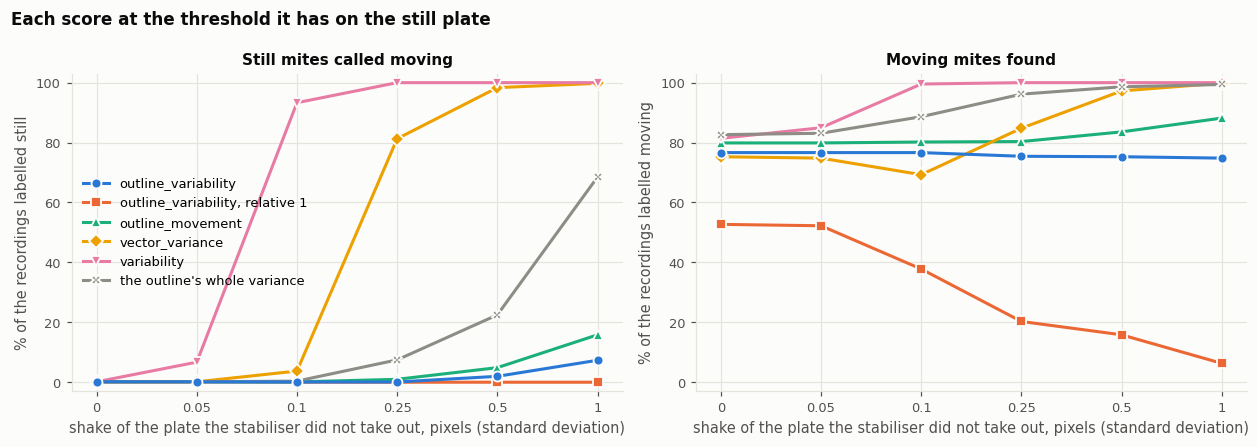

still recordings called moving, % (the threshold calls 0.1% of them moving without a shake):


,0 px,0.05 px,0.1 px,0.25 px,0.5 px,1 px
outline_variability,0.1,0.1,0.1,0.1,2.0,7.3
"outline_variability, relative 1",0.1,0.1,0.0,0.0,0.0,0.0
outline_movement,0.1,0.1,0.1,1.0,4.9,15.8
vector_variance,0.1,0.1,3.7,81.3,98.3,99.8
variability,0.1,6.7,93.3,100.0,100.0,100.0
the outline's whole variance,0.1,0.1,0.4,7.5,22.5,68.5


recordings labelled moving that are found, %:


,0 px,0.05 px,0.1 px,0.25 px,0.5 px,1 px
outline_variability,76.7,76.7,76.7,75.4,75.3,74.8
"outline_variability, relative 1",52.7,52.2,37.8,20.3,15.8,6.3
outline_movement,79.9,79.9,80.2,80.3,83.6,88.2
vector_variance,75.3,74.8,69.3,84.8,97.2,99.8
variability,81.4,84.9,99.5,100.0,100.0,100.0
the outline's whole variance,82.6,83.1,88.6,96.2,98.6,99.4


AUC, moving against still:


,0 px,0.05 px,0.1 px,0.25 px,0.5 px,1 px
outline_variability,0.996,0.996,0.998,0.994,0.982,0.941
"outline_variability, relative 1",0.994,0.993,0.996,0.993,0.984,0.953
outline_movement,0.996,0.996,0.996,0.991,0.969,0.906
vector_variance,0.994,0.992,0.913,0.565,0.482,0.501
variability,0.998,0.970,0.796,0.575,0.490,0.457
the outline's whole variance,0.999,0.998,0.996,0.988,0.954,0.834


the share on one side of a recording labelled moving, in the middle: 0 px: 0.58, 0.05 px: 0.58, 0.1 px: 0.53, 0.25 px: 0.46, 0.5 px: 0.44, 1 px: 0.36; of a still one: 0.044, 0.045, 0.051, 0.057, 0.059, 0.061
a lamp that flickers: still recordings called moving, %, and the AUC:


still called moving, %               AUC  \
                                                    0% 0.5%    2%     0%   
outline_variability                                0.1  0.1   0.1  0.996   
outline_variability, relative 1                    0.1  0.1   0.1  0.994   
outline_movement                                   0.1  0.1   0.1  0.996   
vector_variance                                    0.1  0.1   1.8  0.994   
variability                                        0.1  0.2  57.8  0.998   
the outline's whole variance                       0.1  0.1   0.1  0.999   

                                               
                                  0.5%     2%  
outline_variability              0.996  0.996  
outline_variability, relative 1  0.994  0.994  
outline_movement                 0.996  0.996  
vector_variance                  0.991  0.969  
variability                      0.997  0.931  
the outline's whole variance     0.999  0.999

In [9]:
lamp = seen["lamp"][labelled]
print(f"the lamp in this run: the plate's light varies over the frames of a recording by {np.median(lamp):.2%} of itself in the middle, "
      f"by less than {np.percentile(lamp, 95):.2%} in 95 recordings of 100 and by {lamp.max():.2%} at most")

SHAKES, FLICKERS = (0.0, 0.05, 0.1, 0.25, 0.5, 1.0), (0.005, 0.02)
sampled = moving[ov.sample(run)]              # the sampled recordings, in the order disturbed() gives them: True for those labelled moving
undisturbed = ov.disturbed(run)
limits = {name: np.quantile(values[~sampled], 0.999) for name, values in undisturbed.items()}     # where 1 still recording in 1000 is called moving

def held(scores):
    """Per score, how it does on the disturbed frames at the threshold set on the undisturbed ones."""
    return {name: {"AUC": adf.auc(values[sampled], values[~sampled]), "still called moving, %": 100 * (values[~sampled] >= limits[name]).mean(),
                   "moving found, %": 100 * (values[sampled] >= limits[name]).mean(),
                   "still: median": np.median(values[~sampled]), "moving: median": np.median(values[sampled])} for name, values in scores.items()}

by_shake = {shake: held(ov.disturbed(run, shake=shake)) for shake in SHAKES}
by_flicker = {flicker: held(ov.disturbed(run, flicker=flicker)) for flicker in (0.0,) + FLICKERS}
print(f"scored: {sampled.sum()} recordings labelled moving and {(~sampled).sum()} labelled still, drawn at random")

COLORS = {METRIC: BLUE, RELATIVE: ORANGE, "outline_movement": AQUA, "vector_variance": YELLOW, "variability": MAGENTA, ov.WHOLE: GREY}
MARKS = {METRIC: "o", RELATIVE: "s", "outline_movement": "^", "vector_variance": "D", "variability": "v", ov.WHOLE: "X"}
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.1))
x = np.arange(len(SHAKES))
for ax, measure, title in ((axes[0], "still called moving, %", "Still mites called moving"), (axes[1], "moving found, %", "Moving mites found")):
    for name in COLORS:
        ax.plot(x, [by_shake[shake][name][measure] for shake in SHAKES], color=COLORS[name], marker=MARKS[name], markersize=6.5,
                markeredgecolor=SURFACE, markeredgewidth=1.2, label=name, zorder=4 if name == METRIC else 3)
    ax.set_xticks(x, [f"{shake:g}" for shake in SHAKES])
    ax.set_xlabel("shake of the plate the stabiliser did not take out, pixels (standard deviation)")
    ax.set_title(title, fontsize=10)
    ax.set_ylim(-3, 103)
axes[0].set_ylabel("% of the recordings labelled still")
axes[1].set_ylabel("% of the recordings labelled moving")
axes[0].legend(loc="center left")
fig.suptitle("Each score at the threshold it has on the still plate", fontsize=11, fontweight="bold", color=INK, x=0.01, ha="left")
plt.tight_layout()
plt.show()

def by_level(by, measure, unit):
    return pd.DataFrame({f"{level:g}{unit}": {name: result[name][measure] for name in COLORS} for level, result in by.items()})

print("still recordings called moving, % (the threshold calls 0.1% of them moving without a shake):")
display(by_level(by_shake, "still called moving, %", " px").round(1))
print("recordings labelled moving that are found, %:")
display(by_level(by_shake, "moving found, %", " px").round(1))
print("AUC, moving against still:")
display(by_level(by_shake, "AUC", " px").round(4))
print(f"the share on one side of a recording labelled moving, in the middle: " + ", ".join(f"{shake:g} px: {by_shake[shake][RELATIVE]['moving: median']:.2f}" for shake in SHAKES)
      + f"; of a still one: " + ", ".join(f"{by_shake[shake][RELATIVE]['still: median']:.3f}" for shake in SHAKES))
print("a lamp that flickers: still recordings called moving, %, and the AUC:")
display(pd.concat({"still called moving, %": by_level({100 * level: result for level, result in by_flicker.items()}, "still called moving, %", "%").round(1),
                   "AUC": by_level({100 * level: result for level, result in by_flicker.items()}, "AUC", "%").round(4)}, axis=1))

(text of short)

In [10]:
others = ma.other_runs(run)
short_scores = [ma.scores(other, legs=False) for other in others]
for other, scores in zip(others, short_scores):
    scores[RELATIVE] = ov.one_sidedness(ov.measure(other)["profiles"])
short_labelled = [other.labelled for other in others]
short_moving = np.concatenate([other.moving[where] for other, where in zip(others, short_labelled)])
print("the short recordings: " + ", ".join(f"{other.name} ({other.moving.shape[1]} recordings of {int(np.load(other.path, mmap_mode='r').shape[2])} frames, "
                                           f"{len(other.mites)} mites)" for other in others))
print(f"{short_moving.sum()} mite-recordings labelled moving, {(~short_moving).sum()} labelled still")
rows = {}
for name in ("variability", "outline_movement", METRIC, RELATIVE):
    values = np.concatenate([scores[name][where] for scores, where in zip(short_scores, short_labelled)])
    found = values >= judged[name]["threshold"]
    rows[name] = {"AUC on the short recordings": adf.auc(values[short_moving], values[~short_moving]),
                  "threshold of the long run": judged[name]["threshold"],
                  "moving found with it, %": 100 * found[short_moving].mean(), "still called moving": int(found[~short_moving].sum()),
                  "moving: median": np.median(values[short_moving]), "on the long run": np.median(SCORES[name][moving])}
shown(pd.DataFrame(rows).T.astype({"still called moving": int}),
      {"AUC on the short recordings": "{:.4f}", "threshold of the long run": "{:.4g}", "moving found with it, %": "{:.1f}",
       "moving: median": "{:.3g}", "on the long run": "{:.3g}"})

pooled = [LabelledRun(scores[METRIC], other.moving, other.labelled) for other, scores in zip([run] + others, [table] + short_scores)]
together, error = death_calibration.best_threshold(pooled)
print(f"the best threshold of {METRIC} for the deaths of all {len(pooled)} labelled datasets together: {together:.3f} ({error:.2f} recordings off)")

# what it costs: the time to score one mite in one recording, the best of three goes
patches = [patch(mite, recording) for mite in range(0, n_mites, 6) for recording in range(0, n_recordings, 30)]
config = ma.metric_params()
print(f"time to score one mite in one recording of {N_FRAMES} frames, in one process:")
for name in ("variability", "outline_movement", METRIC):
    cut = MAX_PAD - Analyzer.roi_padding(name, config[name])
    cuts = [frames[:, cut:frames.shape[1] - cut, cut:frames.shape[2] - cut] for frames in patches]
    best = np.inf
    for _go in range(3):
        started = time.perf_counter()
        for frames in cuts:
            Analyzer._motion_score(frames, name, config[name])
        best = min(best, (time.perf_counter() - started) / len(cuts))
    print(f"  {name}: {1000 * best:.2f} ms, {best * n_mites:.2f} s for the {n_mites} mites of a recording")

  ground_truth_60min: 32 mites, 6 recordings
  sample_data: 29 mites, 6 recordings
  ground_truth_90min: 28 mites, 6 recordings


the short recordings: ground_truth_60min (6 recordings of 30 frames, 32 mites), sample_data (6 recordings of 30 frames, 29 mites), ground_truth_90min (6 recordings of 30 frames, 28 mites)
212 mite-recordings labelled moving, 304 labelled still


,AUC on the short recordings,threshold of the long run,"moving found with it, %",still called moving,moving: median,on the long run
variability,0.9982,4.175,96.2,3,15.6,6.41
outline_movement,0.9993,0.2665,95.3,0,0.574,0.364
outline_variability,0.9993,1.638,95.8,0,8.19,2.76
"outline_variability, relative 1",0.9992,0.4603,70.3,0,0.504,0.578


the best threshold of outline_variability for the deaths of all 4 labelled datasets together: 1.638 (1.39 recordings off)
time to score one mite in one recording of 10 frames, in one process:
  variability: 0.03 ms, 0.00 s for the 59 mites of a recording


  outline_movement: 0.89 ms, 0.05 s for the 59 mites of a recording


  outline_variability: 1.08 ms, 0.06 s for the 59 mites of a recording


(text of follows)